---
title: "Anscombe"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Anscombe's Quartet
- **description:** Four small (x, y) datasets with nearly identical summary statistics but strikingly different shapes demonstraing the need to visualize your data.
- **provenance:** Anscombe, F. J. (1973), "Graphs in Statistical Analysis," *The American Statistician* 27(1), 17–21. [URL](https://www.jstor.org/stable/2682899)
- **format:** long / tidy — 44 rows x 3 columns (four datasets of 11 points each).

**Data dictionary**

- `dataset` — *(identifier)* which of the four sets (`I`, `II`, `III`, `IV`).
- `x` — *(measurement)* the x coordinate.
- `y` — *(measurement)* the y coordinate.

**Structure**

- **Rows:** 44 — 4 datasets x 11 points.
- **Columns:** 3.
- **Identifiers:** `dataset`.
- **Measurements:** `x`, `y`.

**Use cases**

- the canonical "why you must visualize" demonstration
- comparing identical means, variances, and correlations across four very different scatter shapes
- small-multiples / faceted plotting


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form, combined

The data set used to produce Anscombe's Quartet, a powerful visualization that demonstrates the value of vizualization itself.

In [3]:
anscombe = sns.load_dataset('anscombe')
anscombe

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


The issuse here is that there are four independent datasets with the same shape combined into one data frame.

By design, they come from completely different populations and distributions.

So, from a datalogical perspective, they shouldn't be combined in a single data frame.

A good idea is to put them into a dictionary.

### Long form, separated

In [4]:
anscombe_dict = {}
for ds_name, ds in anscombe.groupby('dataset'):
    anscombe_dict[ds_name] = ds[['x','y']].reset_index(drop=True)

In [5]:
anscombe_dict['II']

,x,y
0,10.0,9.14
1,8.0,8.14
2,13.0,8.74
3,9.0,8.77
4,11.0,9.26
5,14.0,8.10
6,6.0,6.13
7,4.0,3.10
8,12.0,9.13
9,7.0,7.26


Then, to show the individual scatter plots, we iterate through the dictionary.

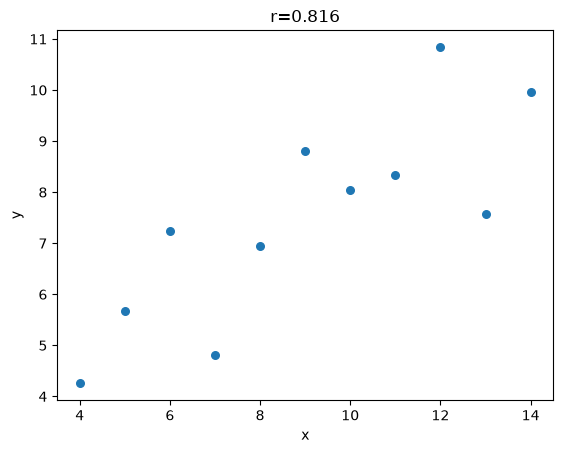

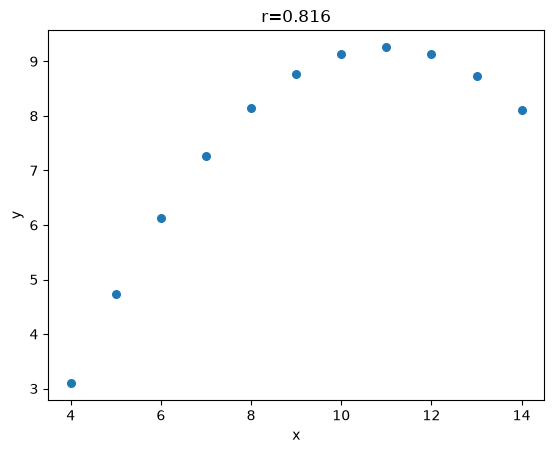

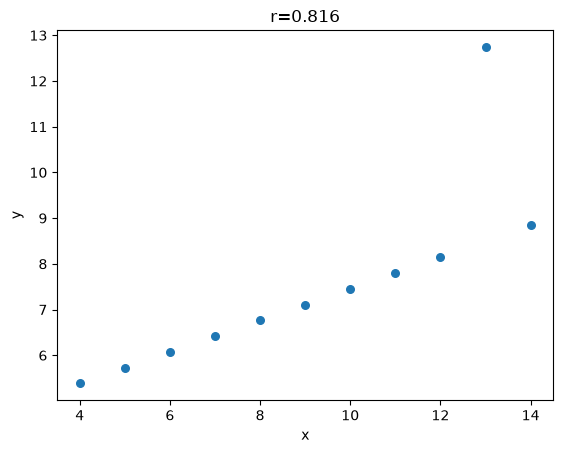

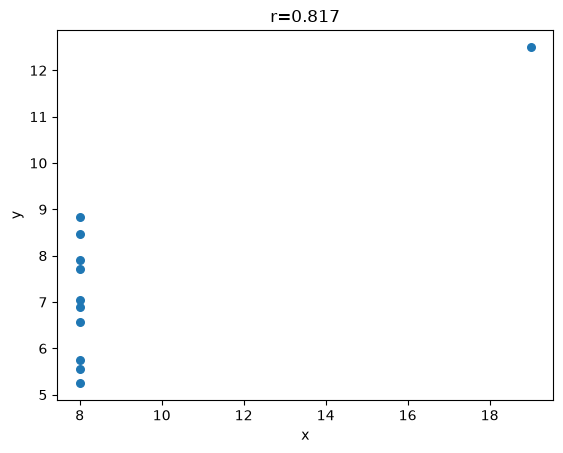

In [6]:
for ds_name, ds in anscombe_dict.items():
    ds.corr()
    ds.plot.scatter(x='x', y='y', s=30, title="r="+str(ds.corr().iloc[0,1].round(3)))

Now, if we _really_ want to, we can combine the data frames into one.

We can do this is with Pandas' `pd.concat()` function.

Here we convert the dictionary into a data frame.

### Pseudo Long form, combined with key column index

We call this "pseudo" because each row is not an observation -- instead, each row contains four observations. 

In [7]:
ANSCOMBE = pd.concat([df for df in anscombe_dict.values()], keys=list(anscombe_dict.keys()), axis=1)
ANSCOMBE

I           II         III           IV       
       x      y     x     y     x      y     x      y
0   10.0   8.04  10.0  9.14  10.0   7.46   8.0   6.58
1    8.0   6.95   8.0  8.14   8.0   6.77   8.0   5.76
2   13.0   7.58  13.0  8.74  13.0  12.74   8.0   7.71
3    9.0   8.81   9.0  8.77   9.0   7.11   8.0   8.84
4   11.0   8.33  11.0  9.26  11.0   7.81   8.0   8.47
5   14.0   9.96  14.0  8.10  14.0   8.84   8.0   7.04
6    6.0   7.24   6.0  6.13   6.0   6.08   8.0   5.25
7    4.0   4.26   4.0  3.10   4.0   5.39  19.0  12.50
8   12.0  10.84  12.0  9.13  12.0   8.15   8.0   5.56
9    7.0   4.82   7.0  7.26   7.0   6.42   8.0   7.91
10   5.0   5.68   5.0  4.74   5.0   5.73   8.0   6.89

In [8]:
ANSCOMBE.II

,x,y
0,10.0,9.14
1,8.0,8.14
2,13.0,8.74
3,9.0,8.77
4,11.0,9.26
5,14.0,8.10
6,6.0,6.13
7,4.0,3.10
8,12.0,9.13
9,7.0,7.26


Again, we iterate through the container (this time a data frame) to produce the individual plots.

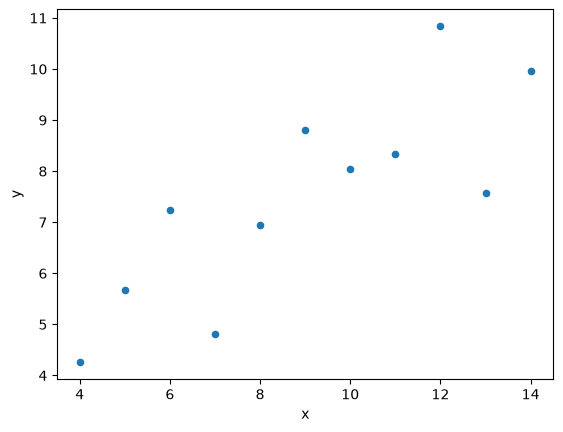

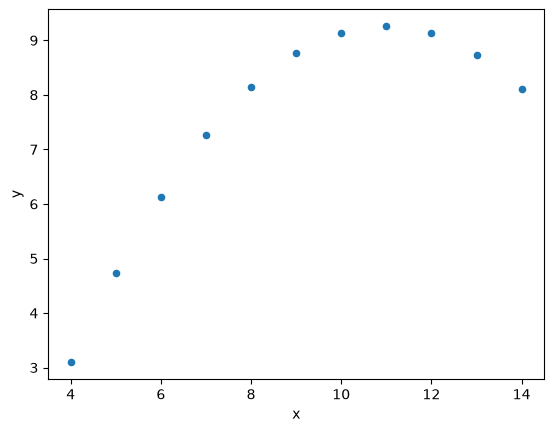

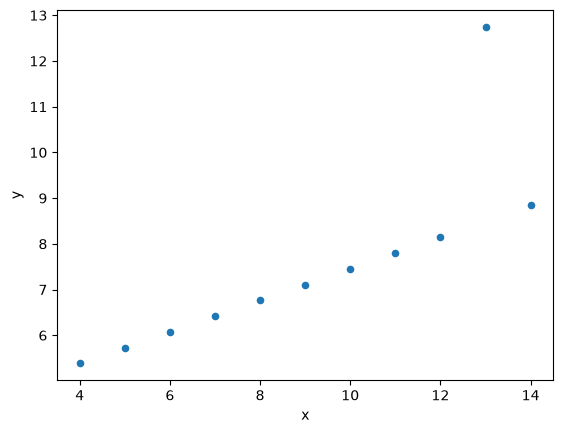

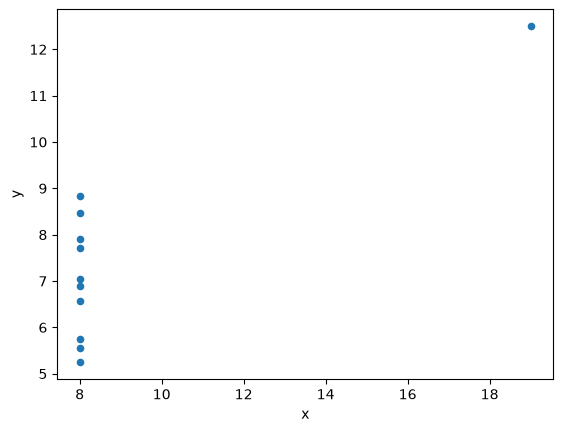

In [9]:
for i, ds_name in enumerate(ANSCOMBE.columns.unique(0).tolist()): 
    ANSCOMBE[ds_name].plot.scatter(x='x', y='y')
plt.show() 

### 